# Этап 3. Бэггинг и оптимизация гиперпараметров

На этом этапе строим ансамбль деревьев через `BaggingRegressor` и подбираем его гиперпараметры с помощью `GridSearchCV` и `KFold`.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

## Загрузка train / validation / test

In [2]:
cwd = Path.cwd()

if (cwd / 'data' / 'processed').exists():
    project_dir = cwd
elif (cwd.parent / 'data' / 'processed').exists():
    project_dir = cwd.parent
else:
    project_dir = Path('..')

processed_dir = project_dir / 'data' / 'processed'
models_dir = project_dir / 'models'
figures_dir = project_dir / 'reports' / 'figures'

models_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(processed_dir / 'train_ordinal_encoded.csv')
val_df = pd.read_csv(processed_dir / 'validation_ordinal_encoded.csv')
test_df = pd.read_csv(processed_dir / 'test_ordinal_encoded.csv')

X_train = train_df.drop(columns=['charges'])
y_train = train_df['charges']

X_val = val_df.drop(columns=['charges'])
y_val = val_df['charges']

X_test = test_df.drop(columns=['charges'])
y_test = test_df['charges']

print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Train: (802, 6)
Validation: (268, 6)
Test: (268, 6)


## Базовый BaggingRegressor

Сначала обучим бэггинг с фиксированными параметрами, чтобы получить базовую точку сравнения.

In [3]:
base_tree = DecisionTreeRegressor(random_state=42)

bagging_baseline = BaggingRegressor(
    estimator=base_tree,
    n_estimators=100,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging_baseline.fit(X_train, y_train)
y_val_pred_baseline = bagging_baseline.predict(X_val)

print('Baseline Bagging on Validation')
print(f"R2:   {r2_score(y_val, y_val_pred_baseline):.4f}")
print(f"MAE:  ${mean_absolute_error(y_val, y_val_pred_baseline):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_val, y_val_pred_baseline):.2f}")

Baseline Bagging on Validation
R2:   0.8314
MAE:  $2880.22
RMSE: $5086.03


## Оптимизация гиперпараметров через KFold и GridSearchCV

Оптимизируем параметры самого бэггинга и параметры базового дерева. Параметры дерева указываются через префикс `estimator__`, потому что дерево находится внутри `BaggingRegressor`.

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_samples': [0.7, 1.0],
    'max_features': [0.8, 1.0],
    'estimator__max_depth': [4, 6, 8, None],
    'estimator__min_samples_leaf': [1, 4, 8]
}

bagging_for_search = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=bagging_for_search,
    param_grid=param_grid,
    scoring='r2',
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

best_bagging_cv = grid_search.best_estimator_
y_val_pred_grid = best_bagging_cv.predict(X_val)

print('Best parameters from GridSearchCV:')
print(grid_search.best_params_)
print(f"Best mean CV R2: {grid_search.best_score_:.4f}")
print('\nTuned Bagging on Validation')
print(f"R2:   {r2_score(y_val, y_val_pred_grid):.4f}")
print(f"MAE:  ${mean_absolute_error(y_val, y_val_pred_grid):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_val, y_val_pred_grid):.2f}")

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results[['mean_test_score', 'mean_train_score', 'params']].sort_values(
    by='mean_test_score',
    ascending=False
).head(10)

Best parameters from GridSearchCV:
{'estimator__max_depth': 4, 'estimator__min_samples_leaf': 4, 'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 100}
Best mean CV R2: 0.8571

Tuned Bagging on Validation
R2:   0.8563
MAE:  $2703.43
RMSE: $4695.56


,mean_test_score,mean_train_score,params
15,0.857133,0.885458,"{'estimator__max_depth': 4, 'estimator__min_sa..."
23,0.857121,0.883803,"{'estimator__max_depth': 4, 'estimator__min_sa..."
22,0.856888,0.883715,"{'estimator__max_depth': 4, 'estimator__min_sa..."
21,0.856871,0.882708,"{'estimator__max_depth': 4, 'estimator__min_sa..."
14,0.856859,0.885283,"{'estimator__max_depth': 4, 'estimator__min_sa..."
13,0.856840,0.885296,"{'estimator__max_depth': 4, 'estimator__min_sa..."
20,0.856338,0.882388,"{'estimator__max_depth': 4, 'estimator__min_sa..."
12,0.856238,0.885184,"{'estimator__max_depth': 4, 'estimator__min_sa..."
7,0.855733,0.889029,"{'estimator__max_depth': 4, 'estimator__min_sa..."
45,0.855641,0.891151,"{'estimator__max_depth': 6, 'estimator__min_sa..."


## Финальная проверка на Test композиции решающих деревьев

После выбора гиперпараметров обучаем модель на `Train + Validation` и только затем проверяем на отложенной тестовой выборке.

In [5]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_bagging = clone(grid_search.best_estimator_)

best_bagging.fit(X_train_full, y_train_full)
y_test_pred = best_bagging.predict(X_test)

print('Final tuned Bagging on Test')
print(f"R2:   {r2_score(y_test, y_test_pred):.4f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_test, y_test_pred):.2f}")

joblib.dump(best_bagging, models_dir / 'bagging_gridsearch_model.pkl')
print('Saved model:', models_dir / 'bagging_gridsearch_model.pkl')

Final tuned Bagging on Test
R2:   0.8435
MAE:  $2382.23
RMSE: $4448.89
Saved model: c:\Users\bulki\OneDrive\Документы\GitHub\Practice_DecisionTreeRegressor\models\bagging_gridsearch_model.pkl


## Визуальный анализ ошибок

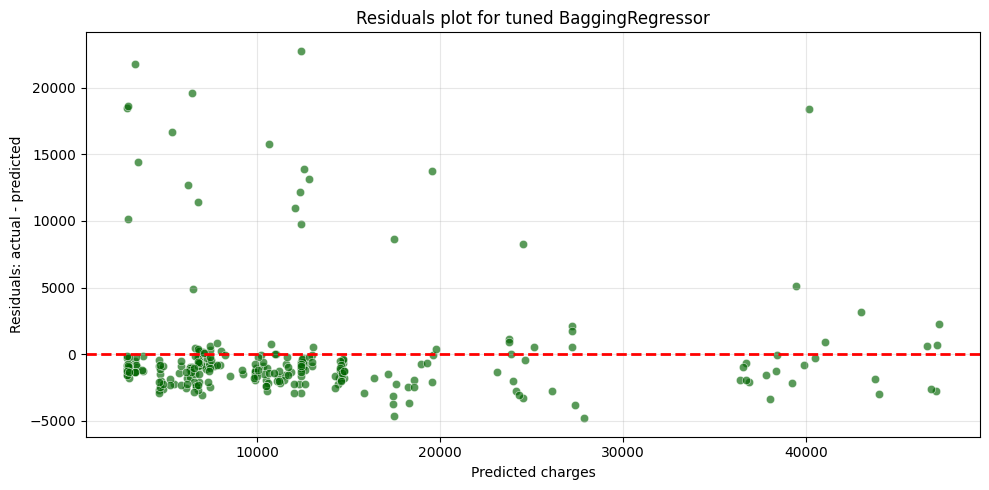

In [6]:
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.65, color='darkgreen')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals plot for tuned BaggingRegressor')
plt.xlabel('Predicted charges')
plt.ylabel('Residuals: actual - predicted')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'bagging_residuals_test.png', dpi=200, bbox_inches='tight')
plt.show()

# Случайный лес


## Базовая модель

In [7]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
print(f"R2:   {r2_score(y_val, rf_pred):.4f}")
print(f"MAE:  ${mean_absolute_error(y_val, rf_pred):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_val, rf_pred):.2f}")

R2:   0.8300
MAE:  $2898.90
RMSE: $5106.27


# Проведем оптимизацию по параметрам

In [8]:
rf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [1, 4, 8],
    'max_features': ['sqrt', 1.0]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='r2',
    cv=rf_cv,
    n_jobs=-1,
    return_train_score=True
)

rf_grid_search.fit(X_train, y_train)

best_rf_cv = rf_grid_search.best_estimator_
rf_val_pred_grid = best_rf_cv.predict(X_val)

print('Best Random Forest parameters:')
print(rf_grid_search.best_params_)
print(f"Best mean CV R2: {rf_grid_search.best_score_:.4f}")
print('\nTuned Random Forest on Validation')
print(f"R2:   {r2_score(y_val, rf_val_pred_grid):.4f}")
print(f"MAE:  ${mean_absolute_error(y_val, rf_val_pred_grid):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_val, rf_val_pred_grid):.2f}")

rf_cv_results = pd.DataFrame(rf_grid_search.cv_results_)
rf_cv_results[['mean_test_score', 'mean_train_score', 'params']].sort_values(
    by='mean_test_score',
    ascending=False
).head(10)


Best Random Forest parameters:
{'max_depth': 4, 'max_features': 1.0, 'min_samples_leaf': 4, 'n_estimators': 100}
Best mean CV R2: 0.8571

Tuned Random Forest on Validation
R2:   0.8563
MAE:  $2703.43
RMSE: $4695.56


,mean_test_score,mean_train_score,params
8,0.857138,0.885457,"{'max_depth': 4, 'max_features': 1.0, 'min_sam..."
10,0.857121,0.883803,"{'max_depth': 4, 'max_features': 1.0, 'min_sam..."
9,0.856754,0.885610,"{'max_depth': 4, 'max_features': 1.0, 'min_sam..."
11,0.856666,0.883966,"{'max_depth': 4, 'max_features': 1.0, 'min_sam..."
6,0.855683,0.889023,"{'max_depth': 4, 'max_features': 1.0, 'min_sam..."
7,0.855126,0.889169,"{'max_depth': 4, 'max_features': 1.0, 'min_sam..."
22,0.854959,0.895753,"{'max_depth': 6, 'max_features': 1.0, 'min_sam..."
23,0.854655,0.896014,"{'max_depth': 6, 'max_features': 1.0, 'min_sam..."
34,0.854155,0.898255,"{'max_depth': 8, 'max_features': 1.0, 'min_sam..."
46,0.854134,0.898384,"{'max_depth': None, 'max_features': 1.0, 'min_..."


## Финальная проверка Random Forest на Test

После подбора гиперпараметров обучаем лучший Random Forest на `Train + Validation` и проверяем его на отложенной `Test` выборке.


In [9]:
rf_train_full = pd.concat([X_train, X_val])
rf_y_train_full = pd.concat([y_train, y_val])

best_rf = clone(rf_grid_search.best_estimator_)
best_rf.fit(rf_train_full, rf_y_train_full)
rf_test_pred = best_rf.predict(X_test)

print('Final tuned Random Forest on Test')
print(f"R2:   {r2_score(y_test, rf_test_pred):.4f}")
print(f"MAE:  ${mean_absolute_error(y_test, rf_test_pred):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_test, rf_test_pred):.2f}")

joblib.dump(best_rf, models_dir / 'random_forest_gridsearch_model.pkl')
print('Saved model:', models_dir / 'random_forest_gridsearch_model.pkl')


Final tuned Random Forest on Test
R2:   0.8435
MAE:  $2382.23
RMSE: $4448.89
Saved model: c:\Users\bulki\OneDrive\Документы\GitHub\Practice_DecisionTreeRegressor\models\random_forest_gridsearch_model.pkl


## Сравнение Bagging и Random Forest

Сравним оптимизированный `BaggingRegressor` и оптимизированный `RandomForestRegressor` на одной и той же test-выборке.


In [10]:
comparison_df = pd.DataFrame([
    {
        'model': 'BaggingRegressor',
        'R2': r2_score(y_test, y_test_pred),
        'MAE': mean_absolute_error(y_test, y_test_pred),
        'RMSE': root_mean_squared_error(y_test, y_test_pred)
    },
    {
        'model': 'RandomForestRegressor',
        'R2': r2_score(y_test, rf_test_pred),
        'MAE': mean_absolute_error(y_test, rf_test_pred),
        'RMSE': root_mean_squared_error(y_test, rf_test_pred)
    }
])

comparison_df.sort_values(by='R2', ascending=False)


,model,R2,MAE,RMSE
1,RandomForestRegressor,0.843544,2382.225569,4448.889489
0,BaggingRegressor,0.843544,2382.225569,4448.889489


## OOB-score comparison

OOB-score estimates model quality using objects that were not included in bootstrap samples for individual trees. Here we compare OOB R2 with cross-validation R2 and test R2 for tuned Bagging and tuned Random Forest.


In [11]:
bagging_oob = clone(grid_search.best_estimator_)
bagging_oob.set_params(oob_score=True)
bagging_oob.fit(X_train_full, y_train_full)

rf_oob = clone(rf_grid_search.best_estimator_)
rf_oob.set_params(oob_score=True, bootstrap=True)
rf_oob.fit(rf_train_full, rf_y_train_full)

oob_comparison_df = pd.DataFrame([
    {
        'model': 'BaggingRegressor',
        'OOB R2': bagging_oob.oob_score_,
        'CV R2': grid_search.best_score_,
        'Test R2': r2_score(y_test, y_test_pred)
    },
    {
        'model': 'RandomForestRegressor',
        'OOB R2': rf_oob.oob_score_,
        'CV R2': rf_grid_search.best_score_,
        'Test R2': r2_score(y_test, rf_test_pred)
    }
])

oob_comparison_df


,model,OOB R2,CV R2,Test R2
0,BaggingRegressor,0.863953,0.857133,0.843544
1,RandomForestRegressor,0.863953,0.857138,0.843544


## Результат OOB-score

Для оптимизированных моделей OOB R2 равен `0.8640` как для Bagging, так и для Random Forest. R2 на кросс-валидации составляет примерно `0.8571`, а R2 на тестовой выборке равен `0.8435` для обеих моделей.

Значения близки, поэтому в данном эксперименте OOB-score дает похожую оценку качества, как и KFold-кросс-валидация. Одинаковые результаты Bagging и Random Forest объясняются тем, что оптимизированный Random Forest выбрал `max_features=1.0`, то есть использует все признаки при каждом разбиении. Из-за этого он становится очень близок к Bagging с такими же настройками деревьев.


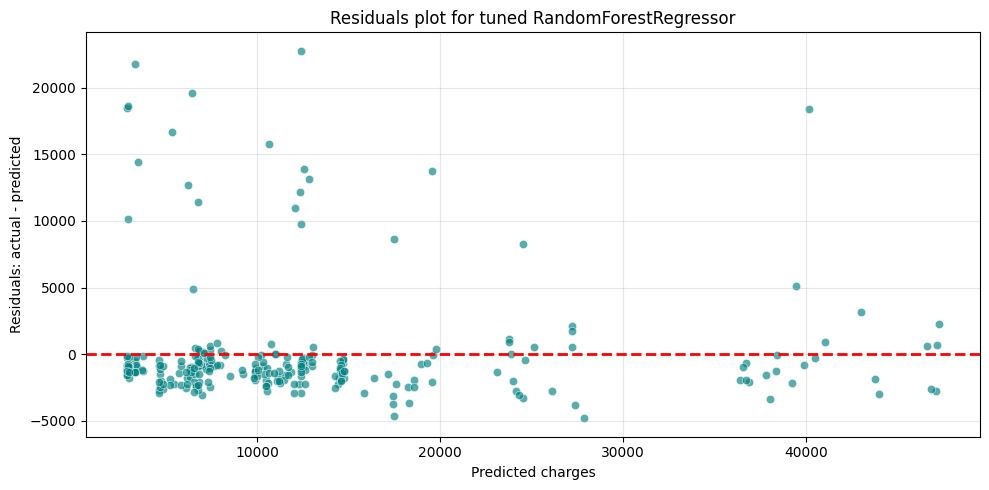

In [12]:
rf_residuals = y_test - rf_test_pred

plt.figure(figsize=(10, 5))
sns.scatterplot(x=rf_test_pred, y=rf_residuals, alpha=0.65, color='teal')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals plot for tuned RandomForestRegressor')
plt.xlabel('Predicted charges')
plt.ylabel('Residuals: actual - predicted')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'random_forest_residuals_test.png', dpi=200, bbox_inches='tight')
plt.show()


# Важность признаков

# Random Forest

In [14]:
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance_df

,feature,importance
4,smoker,0.713078
2,bmi,0.162915
0,age,0.113176
3,children,0.009371
5,region,0.001429
1,sex,0.000031


# Композиция деревьев

In [15]:
bagging_importances = np.mean(
    [tree.feature_importances_ for tree in best_bagging.estimators_],
    axis=0
)

bagging_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': bagging_importances
}).sort_values(by='importance', ascending=False)

bagging_importance_df

,feature,importance
4,smoker,0.713078
2,bmi,0.162915
0,age,0.113176
3,children,0.009371
5,region,0.001429
1,sex,0.000031
